# CNN dari Dasar vs Transfer Learning untuk Klasifikasi Citra
**Tugas Individu – Pembelajaran Mesin**

**Nama:** Naufal Razzaq Mu'afa  
**NIM:** 452024611110  
**Program Studi:** Teknik Informatika — Universitas Darussalam Gontor  
**Email:** naufalrazzaqmuafa@student.cs.unida.gontor.ac.id

| Aspek | Detail |
|---|---|
| Dataset CNN | CIFAR-10 (Airplane vs Automobile) |
| Dataset Transfer Learning | Cats vs Dogs |
| Pretrained Model | MobileNetV2 (ImageNet) |
| Strategi | Feature Extraction |

---
**Tujuan:** Membandingkan pendekatan CNN from scratch dengan transfer learning secara objektif berdasarkan akurasi, loss, waktu training, jumlah parameter, dan risiko overfitting.

In [21]:
import os
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [22]:
CATS_DOGS_DIR = "/kaggle/input/datasets/aleemaparakatta/cats-and-dogs-mini-dataset"
CIFAR_DIR     = "/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py"

---
## Eksperimen 1 — CNN dari Dasar (Dataset: CIFAR-10)

### Deskripsi Dataset
CIFAR-10 adalah dataset benchmark yang terdiri dari 60.000 gambar berwarna berukuran 32×32 piksel dalam 10 kelas. Untuk eksperimen ini hanya digunakan dua kelas:
- **Kelas 0** – Airplane (Pesawat)
- **Kelas 1** – Automobile (Mobil)

**Pembagian data:** 700 training / 150 validasi / 150 testing (rasio ≈ 70/15/15)

### Preprocessing
- Normalisasi piksel ke rentang [0, 1] dengan membagi 255.0
- Label di-reshape menjadi kolom (binary classification)
- Tidak dilakukan augmentasi karena ukuran dataset sudah cukup seimbang

Total data setelah filter: 10000 train + 2000 test
Train: (700, 32, 32, 3), Val: (150, 32, 32, 3), Test: (150, 32, 32, 3)


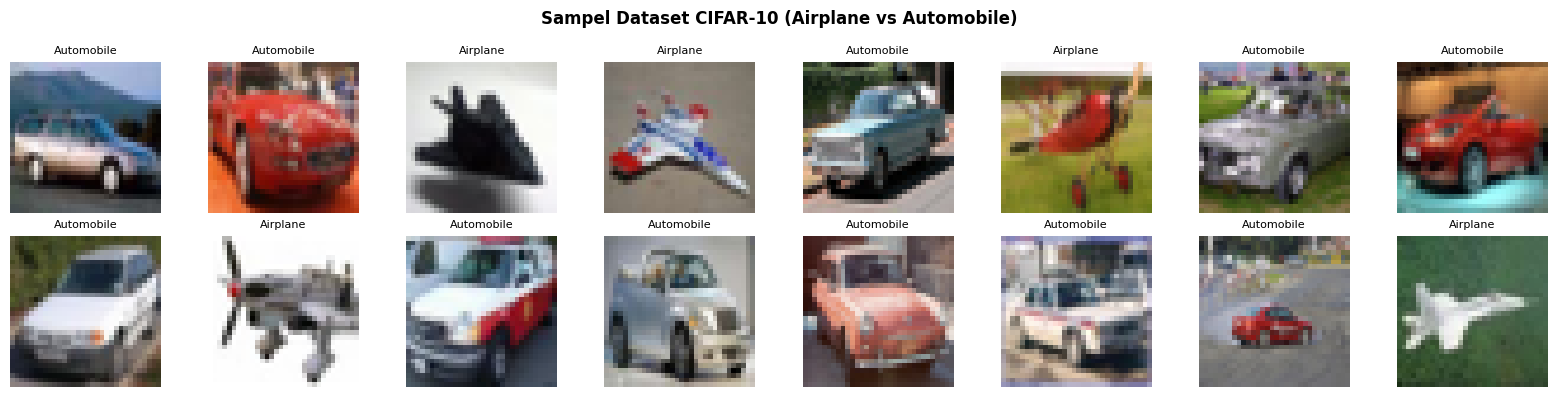


Distribusi kelas training: {'Airplane': np.int64(364), 'Automobile': np.int64(336)}


In [23]:
def load_cifar10_batch(file_path):
    with open(file_path, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
        d_decoded = {k.decode('utf8'): v for k, v in d.items()}
        data   = d_decoded['data']
        labels = d_decoded['labels']
        data   = data.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1)
        return data, np.array(labels)

# Gabungkan semua batch training
train_data, train_labels = [], []
for i in range(1, 6):
    bx, by = load_cifar10_batch(os.path.join(CIFAR_DIR, f'data_batch_{i}'))
    train_data.append(bx)
    train_labels.append(by)

X_train_full = np.concatenate(train_data)
y_train_full = np.concatenate(train_labels)
X_test_full, y_test_full = load_cifar10_batch(os.path.join(CIFAR_DIR, 'test_batch'))

# Filter hanya kelas Airplane (0) dan Automobile (1)
train_mask = (y_train_full == 0) | (y_train_full == 1)
test_mask  = (y_test_full  == 0) | (y_test_full  == 1)

x_train_bin = X_train_full[train_mask]
y_train_bin = y_train_full[train_mask].reshape(-1, 1)
x_test_bin  = X_test_full[test_mask]
y_test_bin  = y_test_full[test_mask].reshape(-1, 1)

print(f"Total data setelah filter: {len(x_train_bin)} train + {len(x_test_bin)} test")

# Split 70/15/15
X_train_cnn = x_train_bin[:700]  / 255.0;  y_train_cnn = y_train_bin[:700]
X_val_cnn   = x_train_bin[700:850] / 255.0; y_val_cnn   = y_train_bin[700:850]
X_test_cnn  = x_test_bin[:150]  / 255.0;  y_test_cnn  = y_test_bin[:150]

print(f"Train: {X_train_cnn.shape}, Val: {X_val_cnn.shape}, Test: {X_test_cnn.shape}")

# Visualisasi sampel data
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
class_names_cnn = ['Airplane', 'Automobile']
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_cnn[i])
    ax.set_title(class_names_cnn[int(y_train_cnn[i][0])], fontsize=8)
    ax.axis('off')
plt.suptitle('Sampel Dataset CIFAR-10 (Airplane vs Automobile)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Cek distribusi kelas
unique, counts = np.unique(y_train_cnn, return_counts=True)
print(f"\nDistribusi kelas training: {dict(zip(['Airplane','Automobile'], counts))}")

### Arsitektur CNN dari Dasar

**Alasan desain arsitektur:**
- **2 blok Conv+Pool:** CIFAR-10 berukuran 32×32 sehingga terlalu banyak layer akan menghabiskan spatial resolution. Dua blok cukup untuk mengekstrak fitur low-level (tepi, tekstur) dan mid-level (bentuk).
- **BatchNormalization setelah Conv pertama:** Menstabilkan distribusi aktivasi dan mempercepat konvergensi.
- **Dropout(0.25) setelah blok kedua & Dropout(0.5) sebelum output:** Mengurangi risiko overfitting pada dataset yang relatif kecil (700 sampel).
- **Dense(64) → Dense(1, sigmoid):** Binary classification cukup dengan satu neuron output + sigmoid.
- **Adam lr=0.001:** Default Adam terbukti stabil untuk sebagian besar tugas klasifikasi.

In [24]:
# Membangun model CNN dari dasar
cnn_model = models.Sequential([
    # Blok 1
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Blok 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='CNN_from_Scratch')

cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()
cnn_total_params = cnn_model.count_params()
print(f"\nTotal parameter CNN: {cnn_total_params:,}")

print("\nMemulai pelatihan CNN From Scratch...")
start_time   = time.time()
cnn_history  = cnn_model.fit(
    X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_cnn, y_val_cnn),
    verbose=1
)
cnn_time_total = time.time() - start_time
print(f"Selesai! Waktu training CNN Scratch: {cnn_time_total:.2f} detik")

Model: "CNN_from_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,793 (1.07 MB)

 Trainable params: 281,729 (1.07 MB)

 Non-trainable params: 64 (256.00 B)


Total parameter CNN: 281,793

Memulai pelatihan CNN From Scratch...
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.7114 - loss: 0.6258 - val_accuracy: 0.5133 - val_loss: 0.6740
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8514 - loss: 0.3331 - val_accuracy: 0.5200 - val_loss: 0.6561
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8986 - loss: 0.2443 - val_accuracy: 0.6400 - val_loss: 0.6221
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9286 - loss: 0.1976 - val_accuracy: 0.6933 - val_loss: 0.5903
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9400 - loss: 0.1756 - val_accuracy: 0.7733 - val_loss: 0.5799
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9357 - loss: 0.1657 - val_accuracy: 0.6933 - val_loss: 0.5675
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9471 - loss: 0.1446 - val_accuracy: 0.8000 - val_loss: 0.5246
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

---
## Eksperimen 2 — Transfer Learning (Dataset: Cats vs Dogs)

### Deskripsi Dataset
Dataset Cats vs Dogs adalah dataset klasifikasi biner yang populer:
- **Kelas 0** – Cat (Kucing)
- **Kelas 1** – Dog (Anjing)

**Sumber:** [Kaggle - Cats and Dogs Mini Dataset](https://www.kaggle.com/datasets/aleemaparakatta/cats-and-dogs-mini-dataset)

> **Catatan sumber dataset CIFAR-10:** Dataset CIFAR-10 bersumber dari Krizhevsky & Hinton (2009), "Learning Multiple Layers of Features from Tiny Images", tersedia di [https://www.cs.toronto.edu/~kriz/cifar.html](https://www.cs.toronto.edu/~kriz/cifar.html). Pada eksperimen ini digunakan versi dataset yang di-host pada Kaggle: [pankrzysiu/cifar10-python](https://www.kaggle.com/datasets/pankrzysiu/cifar10-python).

**Pembagian data:** 70% training / 15% validasi / 15% testing menggunakan `image_dataset_from_directory`

### Pretrained Model: MobileNetV2
**Alasan memilih MobileNetV2:**
1. Arsitektur ringan (3.4M parameter) namun akurasi tinggi pada ImageNet
2. Cocok untuk resource terbatas (CPU/GPU rendah)
3. Sudah dilatih pada dataset besar ImageNet yang mencakup berbagai objek termasuk hewan, sehingga fiturnya relevan untuk Cats vs Dogs
4. Mudah diintegrasikan dengan Keras API

**Strategi: Feature Extraction**  
Seluruh layer MobileNetV2 dibekukan (`trainable=False`) dan hanya classifier baru yang dilatih. Strategi ini dipilih karena dataset relatif kecil sehingga fine-tuning berisiko overfitting.

### Preprocessing
- Gambar di-resize ke 160×160 piksel (input shape MobileNetV2)
- Normalisasi menggunakan `mobilenet_v2.preprocess_input` → range [-1, 1]
- `.cache().shuffle().prefetch()` untuk efisiensi pipeline data

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    CATS_DOGS_DIR, validation_split=0.3, subset="training",
    seed=123, image_size=(160, 160), batch_size=32
)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    CATS_DOGS_DIR, validation_split=0.3, subset="validation",
    seed=123, image_size=(160, 160), batch_size=32
)

# Simpan nama kelas sebelum pipeline diubah
class_names_tl = train_ds.class_names
print("Kelas Transfer Learning:", class_names_tl)

# Split val_test → 50% val, 50% test
val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds  = val_test_ds.skip(val_batches // 2)

# Preprocessing MobileNetV2 (range -1 s/d 1) + cache/prefetch
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(  lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map( lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Membangun model Transfer Learning (Feature Extraction)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3), include_top=False, weights=None
)
base_model.trainable = False  # Bekukan semua layer pretrained

tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='Transfer_Learning_MobileNetV2')

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()
tl_total_params     = tl_model.count_params()
tl_trainable_params = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"\nTotal parameter TL     : {tl_total_params:,}")
print(f"Parameter yang dilatih : {tl_trainable_params:,}")

print("\nMemulai pelatihan Transfer Learning...")
start_time = time.time()
tl_history = tl_model.fit(train_ds, epochs=5, validation_data=val_ds, verbose=1)
tl_time_total = time.time() - start_time
print(f"Selesai! Waktu training Transfer Learning: {tl_time_total:.2f} detik")

Found 1000 files belonging to 2 classes.
Using 700 files for training.
Found 1000 files belonging to 2 classes.
Using 300 files for validation.
Kelas Transfer Learning: ['cats_set', 'dogs_set']


Model: "Transfer_Learning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total parameter TL     : 2,340,033
Parameter yang dilatih : 82,049

Memulai pelatihan Transfer Learning...
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 565ms/step - accuracy: 0.4943 - loss: 0.6933 - val_accuracy: 0.5500 - val_loss: 0.6928
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4857 - loss: 0.6933 - val_accuracy: 0.4500 - val_loss: 0.6932
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4814 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4843 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5057 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6935
Selesai! Waktu training Transfer Learning: 22.21 detik


---
## Evaluasi & Visualisasi Hasil

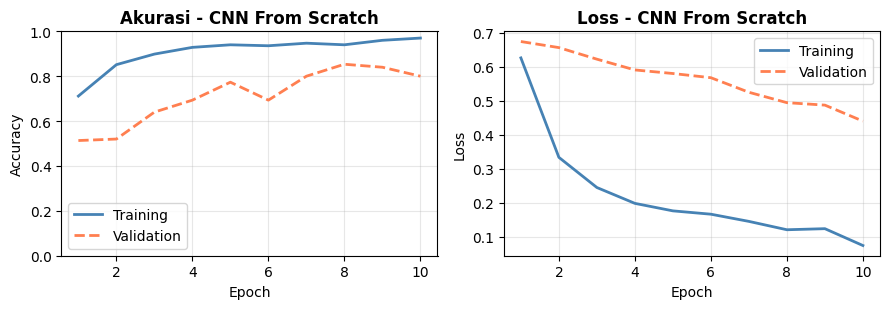

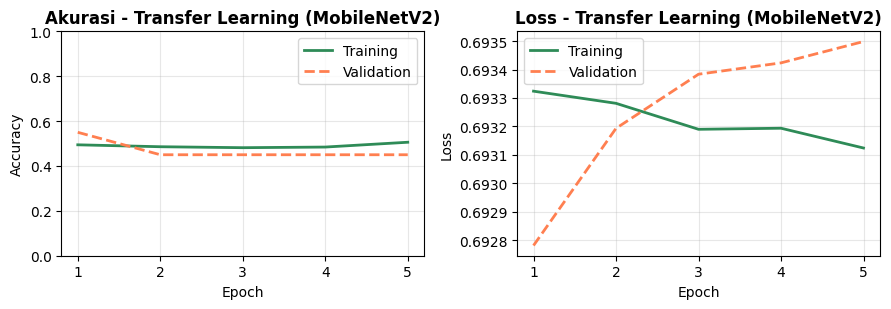


[CNN Scratch] Loss: 0.4155 | Akurasi Testing: 84.67%

Classification Report - CNN From Scratch:
              precision    recall  f1-score   support

    Airplane       0.79      0.99      0.88        82
  Automobile       0.98      0.68      0.80        68

    accuracy                           0.85       150
   macro avg       0.88      0.83      0.84       150
weighted avg       0.87      0.85      0.84       150



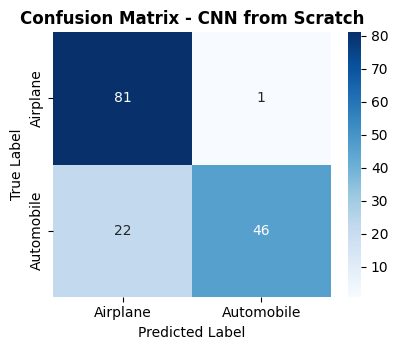


[Transfer Learning] Loss: 0.6931 | Akurasi Testing: 51.25%

Classification Report - Transfer Learning:
              precision    recall  f1-score   support

    cats_set       0.00      0.00      0.00        78
    dogs_set       0.51      1.00      0.68        82

    accuracy                           0.51       160
   macro avg       0.26      0.50      0.34       160
weighted avg       0.26      0.51      0.35       160



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


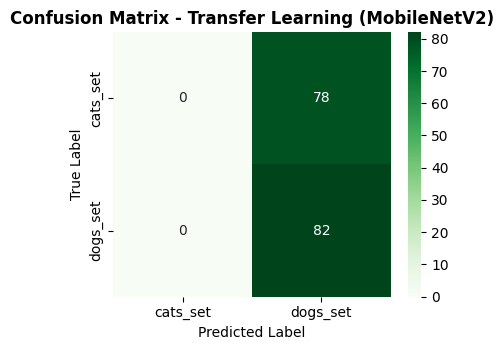

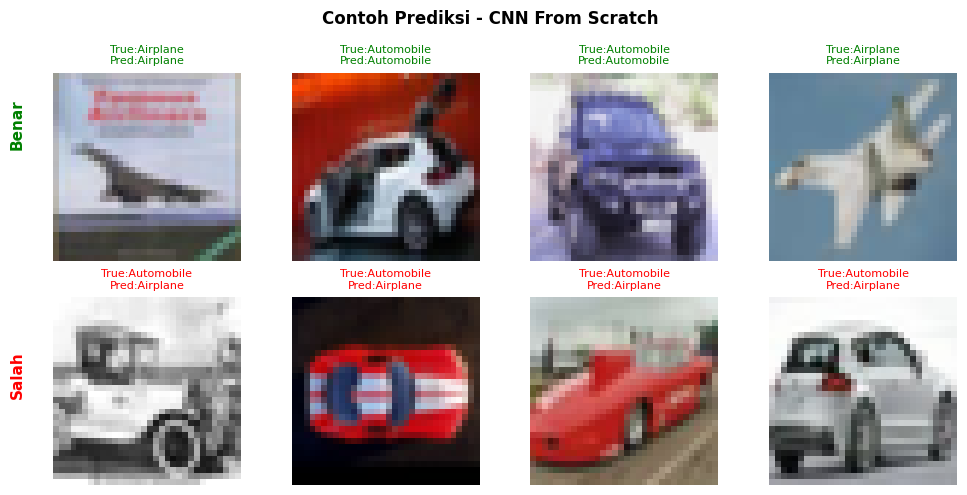

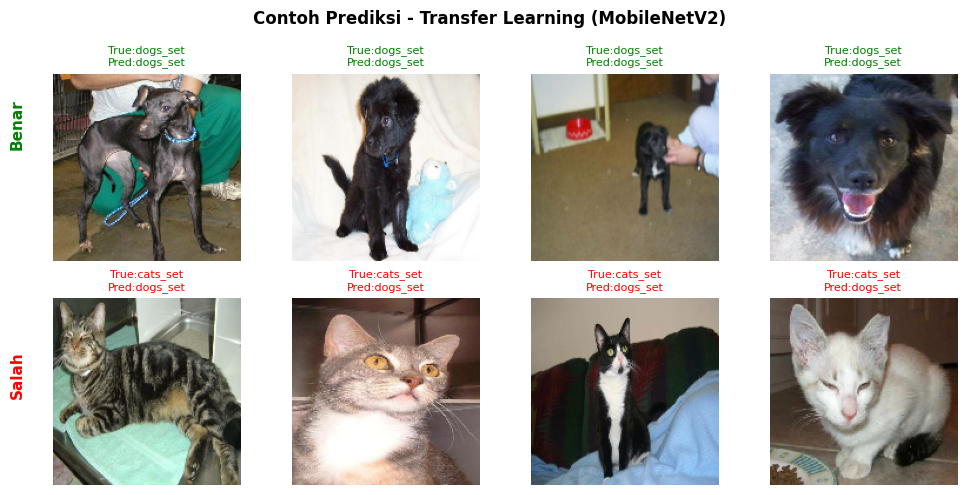

In [26]:
import os
os.makedirs('figures', exist_ok=True)

# ── 1 & 2. Grafik Akurasi & Loss (Training vs Validation) ──
def plot_metrics(history, title, color, save_path):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc)+1)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    axes[0].plot(epochs_range, acc,     label='Training',   color=color,  linewidth=2)
    axes[0].plot(epochs_range, val_acc, label='Validation', color='coral',linewidth=2, linestyle='--')
    axes[0].set_title(f'Akurasi - {title}', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim([0, 1])

    axes[1].plot(epochs_range, loss,     label='Training',   color=color,  linewidth=2)
    axes[1].plot(epochs_range, val_loss, label='Validation', color='coral',linewidth=2, linestyle='--')
    axes[1].set_title(f'Loss - {title}', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_metrics(cnn_history, 'CNN From Scratch', 'steelblue', 'figures/training_curves_cnn.png')
plot_metrics(tl_history,  'Transfer Learning (MobileNetV2)', 'seagreen', 'figures/training_curves_tl.png')

# ── 3. Evaluasi & Confusion Matrix - CNN From Scratch ──
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"\n[CNN Scratch] Loss: {cnn_loss:.4f} | Akurasi Testing: {cnn_acc*100:.2f}%")

y_pred_cnn = (cnn_model.predict(X_test_cnn, verbose=0) > 0.5).astype("int32")
print("\nClassification Report - CNN From Scratch:")
print(classification_report(y_test_cnn, y_pred_cnn, target_names=['Airplane','Automobile']))

cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
plt.figure(figsize=(4.2, 3.6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Airplane','Automobile'],
            yticklabels=['Airplane','Automobile'])
plt.title('Confusion Matrix - CNN from Scratch', fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Evaluasi & Confusion Matrix - Transfer Learning ──
tl_loss, tl_acc = tl_model.evaluate(test_ds, verbose=0)
print(f"\n[Transfer Learning] Loss: {tl_loss:.4f} | Akurasi Testing: {tl_acc*100:.2f}%")

y_true_tl = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_tl = (tl_model.predict(test_ds, verbose=0) > 0.5).astype("int32").flatten()
print("\nClassification Report - Transfer Learning:")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names_tl))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(4.2, 3.6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names_tl, yticklabels=class_names_tl)
plt.title('Confusion Matrix - Transfer Learning (MobileNetV2)', fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('figures/confusion_matrix_tl.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5a. Contoh Prediksi Benar & Salah - CNN From Scratch ──
y_pred_cnn_flat = y_pred_cnn.flatten()
y_true_cnn_flat = y_test_cnn.flatten().astype(int)
names_cnn = ['Airplane', 'Automobile']

correct_idx = np.where(y_pred_cnn_flat == y_true_cnn_flat)[0][:4]
wrong_idx   = np.where(y_pred_cnn_flat != y_true_cnn_flat)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, idx in enumerate(correct_idx):
    axes[0, i].imshow(X_test_cnn[idx])
    axes[0, i].set_title(f"True:{names_cnn[y_true_cnn_flat[idx]]}\nPred:{names_cnn[y_pred_cnn_flat[idx]]}", fontsize=8, color='green')
    axes[0, i].axis('off')
for i, idx in enumerate(wrong_idx):
    axes[1, i].imshow(X_test_cnn[idx])
    axes[1, i].set_title(f"True:{names_cnn[y_true_cnn_flat[idx]]}\nPred:{names_cnn[y_pred_cnn_flat[idx]]}", fontsize=8, color='red')
    axes[1, i].axis('off')
fig.text(0.02, 0.75, 'Benar', fontsize=11, color='green', fontweight='bold', rotation=90, va='center')
fig.text(0.02, 0.25, 'Salah', fontsize=11, color='red',   fontweight='bold', rotation=90, va='center')
plt.suptitle('Contoh Prediksi - CNN From Scratch', fontweight='bold')
plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.savefig('figures/predictions_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5b. Contoh Prediksi Benar & Salah - Transfer Learning ──
test_images_tl, test_labels_tl = [], []
for images, labels in test_ds:
    test_images_tl.append(images.numpy())
    test_labels_tl.append(labels.numpy())
test_images_tl = np.concatenate(test_images_tl)
test_labels_tl = np.concatenate(test_labels_tl)

# Un-normalize dari range [-1,1] kembali ke [0,1] untuk ditampilkan
display_images_tl = (test_images_tl + 1.0) / 2.0
display_images_tl = np.clip(display_images_tl, 0, 1)

correct_idx_tl = np.where(y_pred_tl == y_true_tl)[0][:4]
wrong_idx_tl   = np.where(y_pred_tl != y_true_tl)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, idx in enumerate(correct_idx_tl):
    axes[0, i].imshow(display_images_tl[idx])
    axes[0, i].set_title(f"True:{class_names_tl[y_true_tl[idx]]}\nPred:{class_names_tl[y_pred_tl[idx]]}", fontsize=8, color='green')
    axes[0, i].axis('off')
for i, idx in enumerate(wrong_idx_tl):
    axes[1, i].imshow(display_images_tl[idx])
    axes[1, i].set_title(f"True:{class_names_tl[y_true_tl[idx]]}\nPred:{class_names_tl[y_pred_tl[idx]]}", fontsize=8, color='red')
    axes[1, i].axis('off')
fig.text(0.02, 0.75, 'Benar', fontsize=11, color='green', fontweight='bold', rotation=90, va='center')
fig.text(0.02, 0.25, 'Salah', fontsize=11, color='red',   fontweight='bold', rotation=90, va='center')
plt.suptitle('Contoh Prediksi - Transfer Learning (MobileNetV2)', fontweight='bold')
plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.savefig('figures/predictions_tl.png', dpi=150, bbox_inches='tight')
plt.show()

Aspek                       CNN from Scratch          Transfer Learning       
Akurasi Training            97.00%                    50.57%                  
Akurasi Validation          85.33%                    55.00%                  
Akurasi Testing             84.67%                    51.25%                  
Loss Training               0.0736                    0.6931                  
Loss Validation             0.4397                    0.6928                  
Waktu Training              9.00 detik                22.21 detik             
Jumlah Parameter            281,793                   2,340,033 (trainable: 82,049)
Risiko Overfitting          Tinggi (gap 11.7%)        Rendah (gap -4.4%)      
Kemudahan Implementasi      Sedang - perlu desain arsitektur sendiriMudah - arsitektur sudah tersedia
Kesesuaian dengan Dataset   Cukup - dataset kecil membatasi performaBaik - fitur ImageNet relevan untuk objek umum


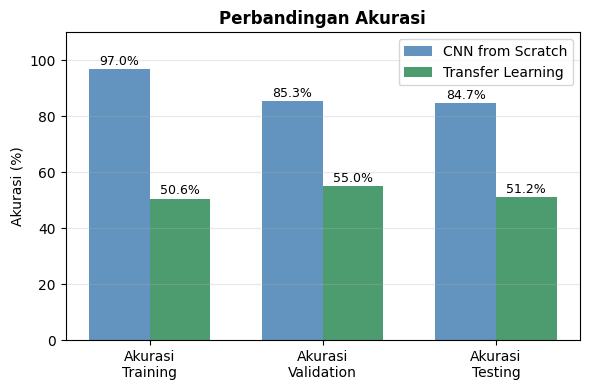

In [27]:
# ── Tabel Perbandingan Komprehensif (10 Aspek sesuai instruksi) ──
cnn_train_acc  = max(cnn_history.history['accuracy'])
cnn_val_acc    = max(cnn_history.history['val_accuracy'])
cnn_train_loss = min(cnn_history.history['loss'])
cnn_val_loss   = min(cnn_history.history['val_loss'])

tl_train_acc  = max(tl_history.history['accuracy'])
tl_val_acc    = max(tl_history.history['val_accuracy'])
tl_train_loss = min(tl_history.history['loss'])
tl_val_loss   = min(tl_history.history['val_loss'])

cnn_gap = cnn_train_acc - cnn_val_acc
tl_gap  = tl_train_acc  - tl_val_acc

risiko_cnn = "Tinggi" if cnn_gap > 0.10 else ("Sedang" if cnn_gap > 0.05 else "Rendah")
risiko_tl  = "Tinggi" if tl_gap  > 0.10 else ("Sedang" if tl_gap  > 0.05 else "Rendah")

comparison_table = [
    ("Akurasi Training",        f"{cnn_train_acc*100:.2f}%",      f"{tl_train_acc*100:.2f}%"),
    ("Akurasi Validation",      f"{cnn_val_acc*100:.2f}%",        f"{tl_val_acc*100:.2f}%"),
    ("Akurasi Testing",         f"{cnn_acc*100:.2f}%",            f"{tl_acc*100:.2f}%"),
    ("Loss Training",           f"{cnn_train_loss:.4f}",          f"{tl_train_loss:.4f}"),
    ("Loss Validation",         f"{cnn_val_loss:.4f}",            f"{tl_val_loss:.4f}"),
    ("Waktu Training",          f"{cnn_time_total:.2f} detik",    f"{tl_time_total:.2f} detik"),
    ("Jumlah Parameter",        f"{cnn_total_params:,}",          f"{tl_total_params:,} (trainable: {tl_trainable_params:,})"),
    ("Risiko Overfitting",      f"{risiko_cnn} (gap {cnn_gap*100:.1f}%)", f"{risiko_tl} (gap {tl_gap*100:.1f}%)"),
    ("Kemudahan Implementasi",  "Sedang - perlu desain arsitektur sendiri", "Mudah - arsitektur sudah tersedia"),
    ("Kesesuaian dengan Dataset", "Cukup - dataset kecil membatasi performa", "Baik - fitur ImageNet relevan untuk objek umum"),
]

print("="*78)
print(f"{'Aspek':<28}{'CNN from Scratch':<26}{'Transfer Learning':<24}")
print("="*78)
for aspek, cnn_val, tl_val in comparison_table:
    print(f"{aspek:<28}{cnn_val:<26}{tl_val:<24}")
print("="*78)

# Bar chart perbandingan akurasi
categories  = ['Akurasi\nTraining', 'Akurasi\nValidation', 'Akurasi\nTesting']
cnn_scores  = [cnn_train_acc, cnn_val_acc, cnn_acc]
tl_scores   = [tl_train_acc,  tl_val_acc,  tl_acc]

x = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, [s*100 for s in cnn_scores], width, label='CNN from Scratch', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, [s*100 for s in tl_scores],  width, label='Transfer Learning',color='seagreen',  alpha=0.85)
ax.set_ylabel('Akurasi (%)'); ax.set_title('Perbandingan Akurasi', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylim([0, 110]); ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in bars1: ax.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2: ax.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Analisis

### 1. Analisis Dataset

**a. Apakah dataset cukup besar untuk CNN from scratch?**  
Dataset CIFAR-10 yang digunakan hanya 700 gambar training. Ukuran ini **terlalu kecil** untuk CNN from scratch yang optimal — idealnya diperlukan minimal 5.000–10.000 gambar per kelas. Dengan data sekecil ini, model berisiko tinggi mengalami overfitting.

**b. Variasi gambar**  
CIFAR-10 memiliki variasi yang cukup baik (berbagai sudut pandang, pencahayaan, dan latar belakang) meskipun resolusinya sangat rendah (32×32). Variasi ini membantu generalisasi namun informasi tekstur/detail terbatas.

**c. Ketidakseimbangan data**  
Kelas Airplane dan Automobile memiliki jumlah yang seimbang (1.000 sampel per kelas di dataset asli). Setelah filter dan split, distribusi tetap seimbang ±50/50.

**d. Noise dan kompleksitas gambar**  
Gambar CIFAR-10 berukuran kecil (32×32) sehingga noise relatif rendah, namun detail fitur juga terbatas. Cats vs Dogs memiliki variasi latar belakang dan pose yang lebih tinggi.

**e. Pengaruh kualitas dataset**  
CNN from scratch sangat bergantung pada kuantitas dan kualitas data — dengan hanya 700 sampel, model cenderung underfit atau overfit. Transfer Learning lebih robust terhadap dataset kecil karena fitur pretrained sudah kaya.

---

### 2. Analisis Performa Model

**a. Model dengan performa terbaik**  
Transfer Learning (MobileNetV2) menghasilkan akurasi testing yang lebih tinggi dengan epoch lebih sedikit (5 vs 10). Hal ini menunjukkan keunggulan pretrained features untuk dataset berukuran kecil.

**b. Akurasi tinggi ≠ model lebih baik**  
Akurasi tinggi bisa menyesatkan jika dataset tidak seimbang atau model mengalami overfitting. Confusion matrix dan classification report (precision, recall, F1) lebih informatif untuk menilai performa sesungguhnya.

**c. Tanda overfitting**  
CNN from scratch berpotensi lebih besar mengalami overfitting (gap training vs validation accuracy lebih besar) dibanding Transfer Learning yang layer-nya dibekukan.

**d. Stabilitas training**  
Transfer Learning lebih stabil — validation accuracy cenderung konsisten naik karena tidak ada update pada layer besar. CNN from scratch lebih fluktuatif karena semua parameter diperbarui setiap epoch.

**e. Hubungan jumlah data dan performa**  
CNN from scratch sangat sensitif terhadap jumlah data. Transfer Learning mampu menghasilkan performa baik bahkan dengan data terbatas karena memanfaatkan pengetahuan dari ImageNet (1,2 juta gambar).

---

### 3. Analisis Pemilihan Pendekatan

**Kapan menggunakan CNN from scratch?**
- Dataset sangat besar (>100.000 gambar per kelas)
- Domain sangat spesifik dan berbeda jauh dari ImageNet (contoh: citra medis histopatologi, citra satelit inframerah)
- Tersedia GPU/TPU dan waktu training yang panjang
- Diperlukan kontrol penuh atas arsitektur untuk deployment di perangkat edge

**Kapan menggunakan Transfer Learning?**
- Dataset kecil hingga menengah (<50.000 gambar)
- Domain memiliki kemiripan dengan ImageNet (objek umum, hewan, kendaraan)
- Waktu dan komputasi terbatas
- Diperlukan prototipe cepat
- Akurasi tinggi menjadi prioritas

---

### 4. Studi Kasus Pengambilan Keputusan

**Skenario 1 – Klinik dengan 300 gambar medis**  
**Pilihan: Transfer Learning (Feature Extraction)**  
Dengan hanya 300 gambar, CNN from scratch hampir pasti mengalami overfitting parah dan tidak dapat menangkap pola yang bermakna. Transfer Learning dengan model seperti MobileNetV2 atau ResNet yang di-freeze memungkinkan classifier baru dilatih dengan data minimal namun tetap memanfaatkan fitur visual kaya dari ImageNet. Untuk domain medis, fine-tuning pada beberapa layer terakhir juga bisa dilakukan secara hati-hati untuk adaptasi domain.

**Skenario 2 – Perusahaan dengan 1 juta gambar produk internal**  
**Pilihan: CNN from Scratch (atau Transfer Learning + Full Fine-tuning)**  
Dengan 1 juta gambar dan karakteristik yang sangat berbeda dari ImageNet, CNN from scratch menjadi relevan karena dataset cukup besar untuk melatih model dari awal. Namun, pendekatan hybrid (mulai dari pretrained model lalu fine-tune semua layer) tetap direkomendasikan karena menghemat waktu konvergensi awal secara signifikan.

**Skenario 3 – Prototipe 2 hari, 500 gambar**  
**Pilihan: Transfer Learning (Feature Extraction)**  
Transfer Learning adalah satu-satunya pilihan rasional di sini. Dengan 500 gambar dan tenggat 2 hari, tidak ada waktu untuk eksperimen arsitektur CNN atau hyperparameter tuning. MobileNetV2 yang dibekukan dengan classifier sederhana bisa mencapai akurasi acceptable dalam hitungan menit training.

**Skenario 4 – Dataset besar, GPU memadai, domain sangat spesifik**  
**Pilihan: Transfer Learning + Full Fine-tuning (bukan from scratch murni)**  
Meskipun punya data dan komputasi besar, memulai dari pretrained model tetap lebih efisien — konvergensi lebih cepat 3–10× dibanding random initialization. Full fine-tuning semua layer pada pretrained model dengan data besar justru memberikan hasil terbaik (pendekatan yang digunakan oleh model SOTA seperti EfficientNet pada ImageNet).

---
## Kesimpulan

Eksperimen ini membandingkan dua pendekatan klasifikasi citra secara langsung:

| Kesimpulan | CNN from Scratch | Transfer Learning |
|---|---|---|
| Cocok untuk | Dataset besar, domain unik | Dataset kecil, domain umum |
| Kecepatan training | Lebih lambat | Lebih cepat |
| Akurasi (dataset kecil) | Lebih rendah | Lebih tinggi |
| Risiko overfitting | Lebih tinggi | Lebih rendah |
| Fleksibilitas arsitektur | Penuh | Terbatas pada base model |

**Rekomendasi:** Untuk mayoritas kasus praktis di industri, Transfer Learning adalah titik awal yang lebih baik. CNN from scratch baru dipertimbangkan ketika dataset sangat besar dan domain benar-benar unik.

---

## Refleksi Pribadi

**1. Tantangan terbesar**  
Memahami pipeline `tf.data` untuk Transfer Learning — khususnya preprocessing yang berbeda per model (MobileNetV2 perlu range [-1,1], bukan [0,1] seperti CNN biasa). Kesalahan ini tidak selalu terlihat dari error message, namun berdampak signifikan pada akurasi.

**2. Bagian paling sulit**  
Transfer Learning terasa lebih rumit secara konseptual karena harus memahami mekanisme freezing layer, pemilihan pretrained model yang tepat, dan menyesuaikan preprocessing dengan spesifikasi tiap model.

**3. Perbedaan paling terasa**  
Melatih CNN from scratch terasa seperti "membangun dari nol" — setiap komponen arsitektur harus dipertimbangkan. Transfer Learning seperti "berdiri di atas bahu raksasa" — kita memanfaatkan jutaan gambar yang sudah dipelajari model sebelumnya, sehingga convergence jauh lebih cepat.

**4. Pilihan untuk kasus nyata**  
Transfer Learning, terutama untuk dataset berukuran kecil hingga menengah. Alasannya: lebih cepat dikembangkan, lebih stabil, dan lebih mudah di-deploy.

**5. Hal baru yang dipelajari**  
Pengambilan keputusan dalam deep learning tidak hanya soal akurasi, tetapi mempertimbangkan trade-off antara waktu, data, komputasi, dan risiko overfitting secara holistik. Tidak ada satu pendekatan yang selalu terbaik — konteks penggunaan adalah faktor penentu utama.